# **Pipeline for $k_{app}$** calculation

This notebook exemplifies the pipeline for the calculation of the apparent $in vivo$ turnover number $k_{app}$ of $E. coli$. 

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cobra

cobra.Configuration().solver = "cplex"

# Add paths
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../scripts'))

# Add directories
data_dir = "../data"



## 1. Create enzymes dataframe

In [2]:
# Module imports
from scripts.enzyme_classifier import create_gpr_dataframe, analyze_model_gprs

from cobra.io import load_model
import cobra 

# Load the model
model = load_model("iML1515")

# Create a dataframe of the GPR rules
df_enzymes = create_gpr_dataframe(model)

# Analyze the model
stats = analyze_model_gprs(model)
print(f"\nModel Stats:")
print(f"Total reactions: {stats['total_reactions']}")
print(f"Reactions with GPR: {stats['reactions_with_gpr']}")
print(f"Total genes: {stats['total_genes']}")
print(f"GPR cases: {stats['gpr_complexity']}")
print('\nDataFrame Head:')
print(df_enzymes.head())


Model Stats:
Total reactions: 2712
Reactions with GPR: 2266
Total genes: 1516
GPR cases: {'simple': 1302, 'or_only': 651, 'and_only': 221, 'complex': 92}

DataFrame Head:
    gene       type     rxn subunit             GPR       enzyme_ID gpr_class
0  b2066  homomeric  CYTDK2       -           b2066  b2066_h_CYTDK2    simple
1  b0238  homomeric    XPPT       -           b0238    b0238_h_XPPT    simple
2  b0238  isoenzyme   HXPRT       -  b0238 or b0125   b0238_i_HXPRT   or_only
3  b0125  isoenzyme   HXPRT       -  b0238 or b0125   b0125_i_HXPRT   or_only
4  b0474  isoenzyme   NDPK5       -  b0474 or b2518   b0474_i_NDPK5   or_only


## 1. Get fluxomics simulations across multiple conditions

In [5]:
from scripts.kapp_builder import create_fluxomics_dataframe

fluxomics_df = create_fluxomics_dataframe(flux_method='FBA', GEM=model, 
                                         carbon_uptake=[2, 6, 10], 
                                         oxygen_uptake=[15, 17.5, 20])


Processing condition 1: Carbon=2, Oxygen=15
Condition 1 completed successfully
Processing condition 2: Carbon=2, Oxygen=17.5
Condition 2 completed successfully
Processing condition 3: Carbon=2, Oxygen=20
Condition 3 completed successfully
Processing condition 4: Carbon=6, Oxygen=15
Condition 4 completed successfully
Processing condition 5: Carbon=6, Oxygen=17.5
Condition 5 completed successfully
Processing condition 6: Carbon=6, Oxygen=20
Condition 6 completed successfully
Processing condition 7: Carbon=10, Oxygen=15
Condition 7 completed successfully
Processing condition 8: Carbon=10, Oxygen=17.5
Condition 8 completed successfully
Processing condition 9: Carbon=10, Oxygen=20
Condition 9 completed successfully
Fluxomics dataframe created with 9 conditions


In [6]:
flux_summary = fluxomics_df.set_index("rxn_id").agg(["mean", "std", "min", "max"], axis=1)

In [7]:
from scripts.kapp_builder import create_enzyme_info_dataframe

substrates_df = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "iML1515_substrates.csv")
sequence_df = os.path.join(data_dir, "processed", "UniProt", "iML1515_E coli_83333_UniProt.csv")

enzymes_info_dfs = create_enzyme_info_dataframe(df_enzymes, fluxomics_df, substrates_df, sequence_df)

Processing 9 flux conditions...
Processing flux_cond1...
Rows before filtering: 4624
Completed flux_cond1: 1193 rows after filtering
Processing flux_cond2...
Rows before filtering: 4624
Completed flux_cond2: 1200 rows after filtering
Processing flux_cond3...
Rows before filtering: 4624
Completed flux_cond3: 1200 rows after filtering
Processing flux_cond4...
Rows before filtering: 4624
Completed flux_cond4: 1199 rows after filtering
Processing flux_cond5...
Rows before filtering: 4624
Completed flux_cond5: 1195 rows after filtering
Processing flux_cond6...
Rows before filtering: 4624
Completed flux_cond6: 1195 rows after filtering
Processing flux_cond7...
Rows before filtering: 4624
Completed flux_cond7: 1191 rows after filtering
Processing flux_cond8...
Rows before filtering: 4624
Completed flux_cond8: 1194 rows after filtering
Processing flux_cond9...
Rows before filtering: 4624
Completed flux_cond9: 1190 rows after filtering
Created enzyme info dataframes for 9 conditions


In [8]:
from scripts.kapp_builder import process_enzyme_protein_mapping

paxdb_dir = os.path.join(data_dir, "raw", "PaxDb","511145_ecoli","511145-WHOLE_ORGANISM-integrated.txt")

enzyme_protein_info_dfs = process_enzyme_protein_mapping(enzymes_info_dfs, paxdb_dir, p_total=[0.32, 0.435, 0.55])


Loading PaxDB data from: ../data\raw\PaxDb\511145_ecoli\511145-WHOLE_ORGANISM-integrated.txt
PaxDB data loaded: 4094 rows
Processing 9 conditions × 3 p_total values = 27 combinations

Processing condition: flux_cond1
  Processing p_total=0.32 (1/27)
    Success: 1193 rows, 1184 with protein data
  Processing p_total=0.435 (2/27)
    Success: 1193 rows, 1184 with protein data
  Processing p_total=0.55 (3/27)
    Success: 1193 rows, 1184 with protein data

Processing condition: flux_cond2
  Processing p_total=0.32 (4/27)
    Success: 1200 rows, 1191 with protein data
  Processing p_total=0.435 (5/27)
    Success: 1200 rows, 1191 with protein data
  Processing p_total=0.55 (6/27)
    Success: 1200 rows, 1191 with protein data

Processing condition: flux_cond3
  Processing p_total=0.32 (7/27)
    Success: 1200 rows, 1191 with protein data
  Processing p_total=0.435 (8/27)
    Success: 1200 rows, 1191 with protein data
  Processing p_total=0.55 (9/27)
    Success: 1200 rows, 1191 with prote

In [9]:
from scripts.kapp_builder import calculate_kapp_homomeric

kapp_dfs = calculate_kapp_homomeric(enzyme_protein_info_dfs)


Processing condition: flux_cond1
  Processing p_total=0.32
    Rows before filtering homomeric: 1193
    Rows after filtering homomeric: 458
    Rows before filtering duplicates: 458
    Rows after filtering duplicates: 429
    Calculated kcat_app for 418 enzymes
  Processing p_total=0.435
    Rows before filtering homomeric: 1193
    Rows after filtering homomeric: 458
    Rows before filtering duplicates: 458
    Rows after filtering duplicates: 429
    Calculated kcat_app for 418 enzymes
  Processing p_total=0.55
    Rows before filtering homomeric: 1193
    Rows after filtering homomeric: 458
    Rows before filtering duplicates: 458
    Rows after filtering duplicates: 429
    Calculated kcat_app for 418 enzymes

Processing condition: flux_cond2
  Processing p_total=0.32
    Rows before filtering homomeric: 1200
    Rows after filtering homomeric: 447
    Rows before filtering duplicates: 447
    Rows after filtering duplicates: 423
    Calculated kcat_app for 412 enzymes
  Proce

In [10]:
from scripts.kapp_builder import evaluate_kapp_homomeric

kapp_dfs = evaluate_kapp_homomeric(kapp_dfs)

Filtering kcat_app values above threshold: 1e+06 s⁻¹

Processing condition: flux_cond1
  Processing p_total=0.32
    Original rows: 429
    Filtered rows: 425
    Removed rows: 4
    Removed kcat_app range: 1.40e+08 to 2.66e+10 s⁻¹
  Processing p_total=0.435
    Original rows: 429
    Filtered rows: 425
    Removed rows: 4
    Removed kcat_app range: 1.03e+08 to 1.96e+10 s⁻¹
  Processing p_total=0.55
    Original rows: 429
    Filtered rows: 425
    Removed rows: 4
    Removed kcat_app range: 8.17e+07 to 1.55e+10 s⁻¹

Processing condition: flux_cond2
  Processing p_total=0.32
    Original rows: 423
    Filtered rows: 420
    Removed rows: 3
    Removed kcat_app range: 2.66e+10 to 2.66e+10 s⁻¹
  Processing p_total=0.435
    Original rows: 423
    Filtered rows: 420
    Removed rows: 3
    Removed kcat_app range: 1.96e+10 to 1.96e+10 s⁻¹
  Processing p_total=0.55
    Original rows: 423
    Filtered rows: 420
    Removed rows: 3
    Removed kcat_app range: 1.55e+10 to 1.55e+10 s⁻¹

Proces

In [11]:
from scripts.kapp_builder import get_kmax_homomeric

kmax_results = get_kmax_homomeric(kapp_dfs)

Starting kmax analysis across all conditions and p_total values...
  Added 414 valid entries from flux_cond1, p_total=0.32
  Added 414 valid entries from flux_cond1, p_total=0.435
  Added 414 valid entries from flux_cond1, p_total=0.55
  Added 409 valid entries from flux_cond2, p_total=0.32
  Added 409 valid entries from flux_cond2, p_total=0.435
  Added 409 valid entries from flux_cond2, p_total=0.55
  Added 409 valid entries from flux_cond3, p_total=0.32
  Added 409 valid entries from flux_cond3, p_total=0.435
  Added 409 valid entries from flux_cond3, p_total=0.55
  Added 414 valid entries from flux_cond4, p_total=0.32
  Added 414 valid entries from flux_cond4, p_total=0.435
  Added 414 valid entries from flux_cond4, p_total=0.55
  Added 414 valid entries from flux_cond5, p_total=0.32
  Added 414 valid entries from flux_cond5, p_total=0.435
  Added 414 valid entries from flux_cond5, p_total=0.55
  Added 414 valid entries from flux_cond6, p_total=0.32
  Added 414 valid entries from f

In [12]:
from scripts.kcat_utils import load_kcat_dataset

CPIPred_dir = os.path.join(data_dir, "raw", "CPIPred", "CPI_kcat_scrn.csv")
CatPred_dir = os.path.join(data_dir, "raw", "CatPred", "kcat-random_trainvaltest.csv")

df_cpi, df_catpred = load_kcat_dataset(CPIPred_dir, CatPred_dir)

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kmax in vivo    kcat in vitro  
--------------------------------------------------
Count                396             1,327          
Mean                 8.11e+01        7.23e+03       
Median               1.10e+01        1.43e+01       
Std Dev              3.71e+02        6.32e+04       
P10                  3.05e-02        1.20e-01       
P25                  3.96e-01        1.40e+00       
P75                  3.97e+01        9.20e+01       
P90                  1.64e+02        7.50e+02       
IQR (P25-P75)        3.93e+01        9.06e+01       
Geometric Mean       3.88e+00        1.19e+01       
Geometric Std        3.16e+01        3.60e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kmax in vivo    kcat in vitro  
--------------------------------------------------
Count        

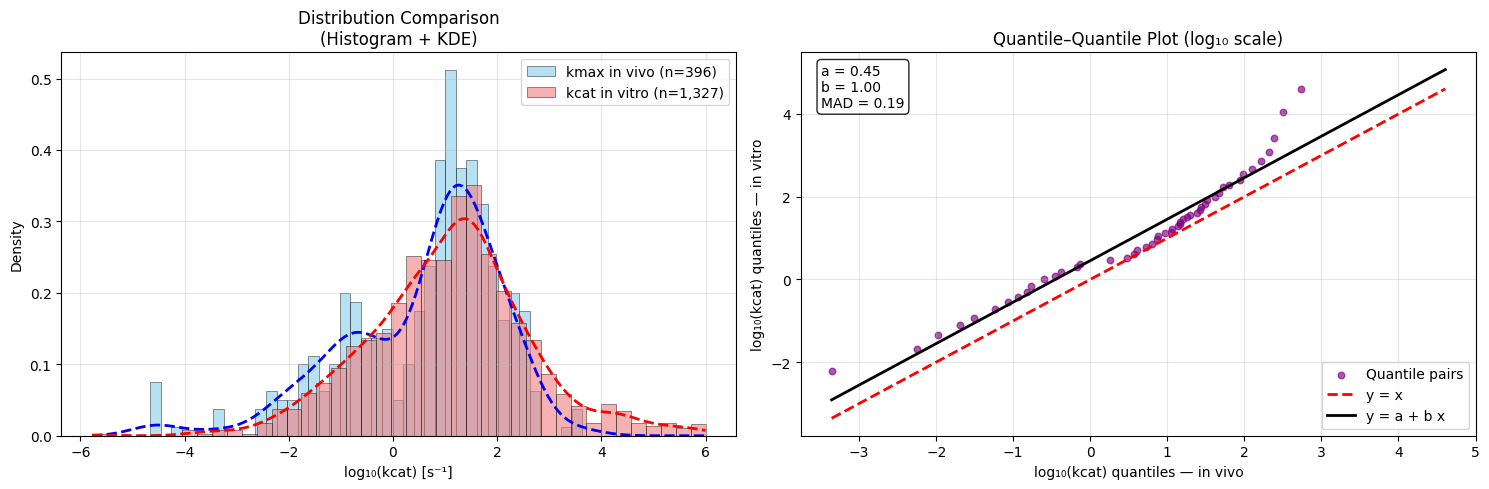

In [ ]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(kmax_results, "kcat_app_max", df_catpred, "kcat_CatPred", label1="kcat in vivo", label2="kcat in vitro")

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kmax_invivo     kcat_CPIPred   
--------------------------------------------------
Count                396             4,504          
Mean                 8.11e+01        4.03e+02       
Median               1.10e+01        5.85e+00       
Std Dev              3.71e+02        1.06e+04       
P10                  3.05e-02        4.21e-02       
P25                  3.96e-01        3.23e-01       
P75                  3.97e+01        9.00e+01       
P90                  1.64e+02        5.10e+02       
IQR (P25-P75)        3.93e+01        8.97e+01       
Geometric Mean       3.88e+00        4.52e+00       
Geometric Std        3.16e+01        3.43e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kmax_invivo     kcat_CPIPred   
--------------------------------------------------
Count        

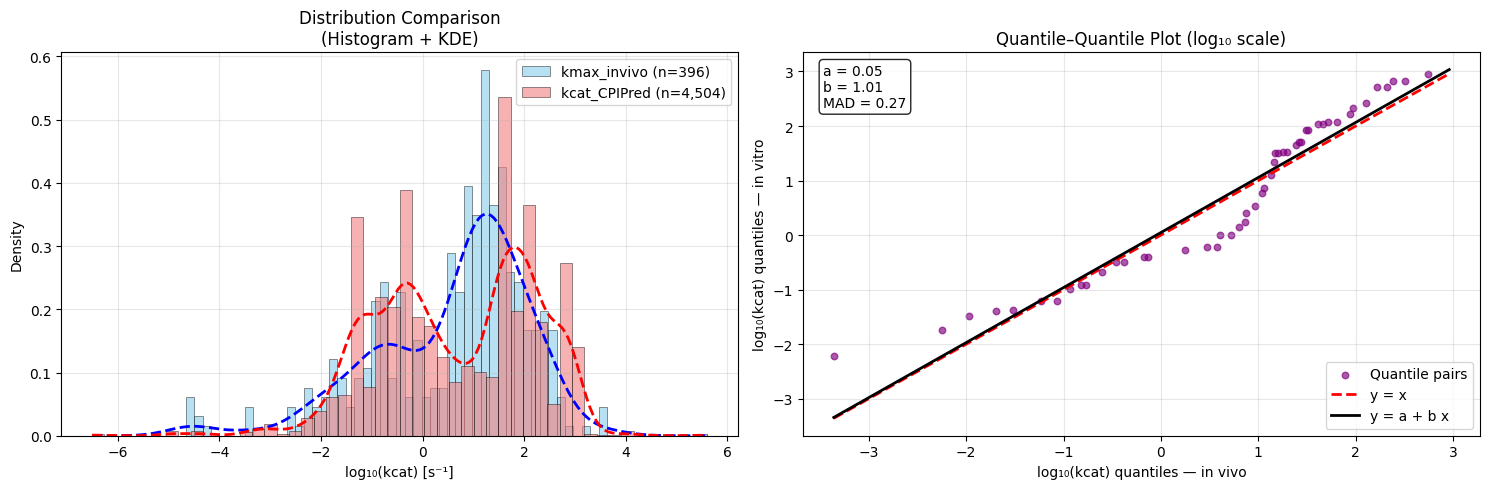

In [14]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(kmax_results, "kcat_app_max", df_cpi, "kcat_CPIPred", label1="kmax_invivo", label2="kcat_CPIPred")

# [PRELIMINARY $k_{app}$]
Using fluxomics data matched to the Crown et al. study (E. coli,  W3110, M9+Glu none)

## a. Merge fluxomics information


In [33]:
fba_exp_df = pd.read_csv(os.path.join(data_dir, "final", "ECOMICS", "exp_vs_FBA.csv"))

df_fluxomics_enzymes = pd.merge(
    df_enzymes,
    fba_exp_df,
    left_on="rxn",
    right_on="rxn_id",
    how="left"
)

df_fluxomics_enzymes = df_fluxomics_enzymes.drop(columns=["rxn_id"])

## b. Merge substrate partners
Using dataframe of substrate partners from kinGEMs pipeline

In [34]:
# Load
iML1515_substrates_dir = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "iML1515_substrates.csv")
df_iML1515_substrates = pd.read_csv(iML1515_substrates_dir)

# Keep just Reaction, SMILES and direction column
df_iML1515_substrates = df_iML1515_substrates[['Reaction', 'SMILES', 'Direction']]

In [35]:
# Merge using reaction ID
df_fluxomics_enzymes = pd.merge(
    df_fluxomics_enzymes,
    df_iML1515_substrates,
    left_on="rxn",
    right_on="Reaction",
    how="left"
)

df_fluxomics_enzymes = df_fluxomics_enzymes.drop(columns=["Reaction"])

In [36]:
# Drop rows with wrong direction-flux
df_fluxomics_enzymes = df_fluxomics_enzymes[
    ((df_fluxomics_enzymes['Direction'] == 'forward') & (df_fluxomics_enzymes['FBA_flux'] >= 0)) |
    ((df_fluxomics_enzymes['Direction'] == 'reverse') & (df_fluxomics_enzymes['FBA_flux'] <= 0))
]

In [37]:
# Drop rows with balancing species - these are not substrates
# where SMILES is '[H+]' or 'O'
df_fluxomics_enzymes = df_fluxomics_enzymes[
    ~df_fluxomics_enzymes['SMILES'].isin(['[H+]', 'O'])
]


In [38]:
# Remove rows with 0 FBA flux 
df_fluxomics_enzymes = df_fluxomics_enzymes[df_fluxomics_enzymes['FBA_flux'] != 0]

## c. Add sequences from UniProt

In [39]:
# Read sequences recovered from UniProt
seq_path = os.path.join(data_dir, "processed", 'UniProt', 'iML1515_E coli_83333_UniProt.csv')
seq_df = pd.read_csv(seq_path)

# Create a dictionary of gene-sequence
seq_mapping = seq_df.set_index('model_gene_id')['sequence'].to_dict()

# Map to dataframe
df_fluxomics_enzymes['sequence'] = df_fluxomics_enzymes['gene'].map(seq_mapping)

## d. . Map proteomics from PaxDb

In [40]:
from scripts.paxdb_mapper import map_paxdb_to_gene

# Load PaxDB file
ecoli_paxdb_dir = os.path.join(data_dir,"raw", "PaxDb","511145_ecoli","511145-WHOLE_ORGANISM-integrated.txt")

# Convert to dataframe
ecoli_paxdb = pd.read_csv(
    ecoli_paxdb_dir,
    sep="\t",
    comment="#",
    header=None,
    names=["gene_name", "string_external_id", "abundance"]  # set column names
)

# Map PaxDB abundances to enzymes by gene ID and calculate protein concentrations
# p_total is the total protein content in g/gDCW
df_fluxomics_enzymes = map_paxdb_to_gene(ecoli_paxdb, df_fluxomics_enzymes, p_total=0.55)

## e. Filter dataframe to keep only homomeric enzymes (i.e. 'simple' gpr class)
TO DO: Add isoenzymes and complexes

In [41]:
df_fluxomics_homomeric = df_fluxomics_enzymes[df_fluxomics_enzymes['gpr_class'] == 'simple']

In [42]:
print(f'Length of ALL enzymes df: {len(df_fluxomics_enzymes)}')
print(f'Length of homomeric enzymes df: {len(df_fluxomics_homomeric)}')

Length of ALL enzymes df: 1204
Length of homomeric enzymes df: 453


## f. Calculate $k_{app}$

In [43]:
# Convert negative fluxes to positive
df_fluxomics_homomeric.loc[:, 'FBA_flux'] = df_fluxomics_homomeric['FBA_flux'].abs()

# COBRA fluxes are in mmol/gDW*h
df_fluxomics_homomeric.loc[:, 'FBA_flux'] = df_fluxomics_homomeric['FBA_flux'] / 3600 # mmol/gDW*s

In [44]:
# Divide flux (mmol/gDW*s) by enzyme concentration (mmol/gDCW) = kcat (1/s)
df_fluxomics_homomeric.loc[:, 'kcat_app'] = df_fluxomics_homomeric['FBA_flux'] / df_fluxomics_homomeric['protein_mmol_gdcw']

C:\Users\lyachinas\AppData\Local\Temp\ipykernel_23452\3962766877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fluxomics_homomeric['kcat_app'] = df_fluxomics_homomeric['FBA_flux'] / df_fluxomics_homomeric['protein_mmol_gdcw']


In [45]:
# Export to csv
df_fluxomics_homomeric.to_csv(os.path.join(data_dir, "final", "kcat_app", "iml1515_homomeric_kcat_app.csv"), index=False)

## Comparisons to $in$ $vitro$: 
### CPI-Pred and CatPred kcat dfs

In [46]:
# Load
CPIPred_dir = os.path.join(data_dir, "raw", "CPIPred", "CPI_kcat_scrn.csv")
CPIPred_df = pd.read_csv(CPIPred_dir)

CatPred_dir = os.path.join(data_dir, "raw", "CatPred", "kcat-random_trainvaltest.csv")
CatPred_df = pd.read_csv(CatPred_dir)

In [ ]:
# Keep only E coli data - this cuts too many enzymes!
CPIPred_df = pd.read_csv(CPIPred_dir)
CatPred_df = CatPred_df[(CatPred_df['taxonomy_id'] == 562) | (CatPred_df['taxonomy_id'] == 83333)]

In [48]:
# Clean for easy merge
CPIPred_df = CPIPred_df[["SEQ", "CMPD_SMILES", "kcat"]]
CPIPred_df = CPIPred_df[CPIPred_df['kcat'].notna()]
CPIPred_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES", "kcat": "kcat_CPIPred"}, inplace=True)

CatPred_df = CatPred_df[["sequence", "reactant_smiles", "value"]]
CatPred_df = CatPred_df[CatPred_df['value'].notna()]
CatPred_df.rename(columns={'reactant_smiles': 'SMILES', "value": "kcat_CatPred"}, inplace=True)

df_kcat = pd.concat([CPIPred_df, CatPred_df])

In [49]:
# Read
df_fluxomics_homomeric_dir = os.path.join(data_dir, "final", "kcat_app", "iml1515_homomeric_kcat_app.csv")
df_fluxomics_homomeric = pd.read_csv(df_fluxomics_homomeric_dir)

# Merge
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, df_kcat, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_invivo     kcat_CPIPred   
--------------------------------------------------
Count                439             4,504          
Mean                 2.25e+09        4.03e+02       
Median               5.28e+00        5.85e+00       
Std Dev              3.78e+10        1.06e+04       
P10                  1.15e-02        4.21e-02       
P25                  1.51e-01        3.23e-01       
P75                  1.97e+01        9.00e+01       
P90                  9.43e+01        5.10e+02       
IQR (P25-P75)        1.96e+01        8.97e+01       
Geometric Mean       2.06e+00        4.52e+00       
Geometric Std        7.46e+01        3.43e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_invivo     kcat_CPIPred   
--------------------------------------------------
Count        

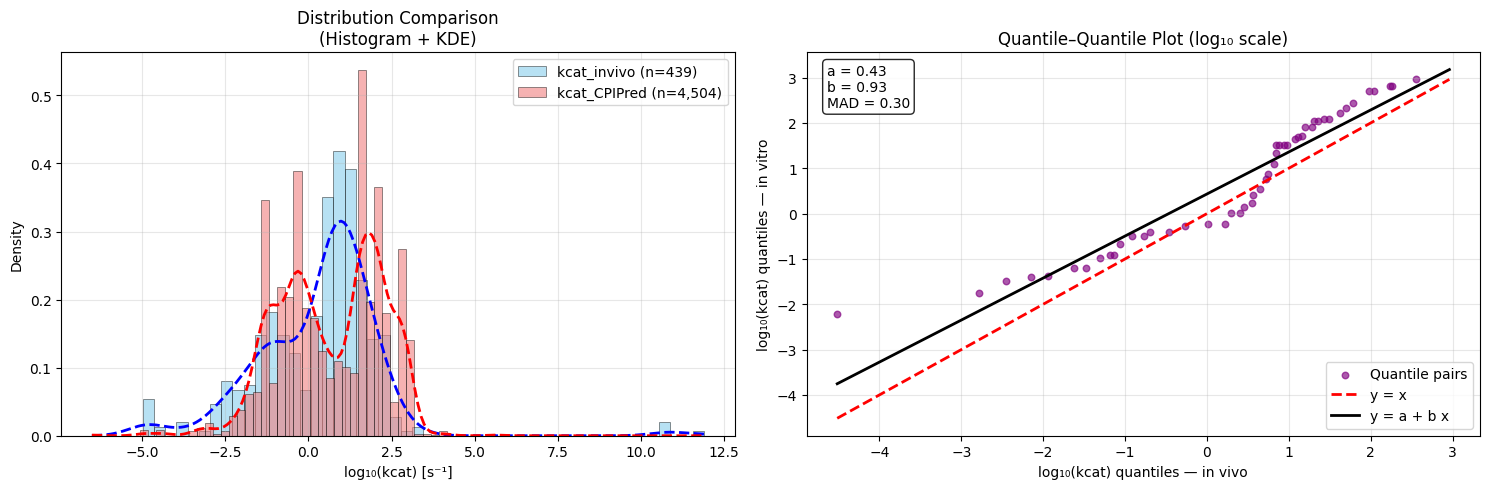

In [50]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_df, "kcat_CPIPred", label1="kcat_invivo", label2="kcat_CPIPred")

### Interpretation of quantile-quantile plot

When comparing in vivo (var $A$) to in vitro (var $B$)

**Intercept $a$:**
- Vertical shift of the regression line.
- Captures the systematic location difference between the two distributions.
    - Here we are comparing all quantiles of the in vivo distribution against the in vitro distribution. This will give us a 'systematic' measure - a consistent shift
- $a=0$ - distributions are aligned, no shift
- $a<1$ - var $B$ is systematically lower than $A$
    - On raw scale, ratio ≈ $10^a$
- $a>1$ - var $B$ is systematically higher than $A$

**Slope $b$:**
- Tilt of the regression line.
- Reflects the relative spread/dispersion of the two distributions.
- $b=1$ - similar spread
- $b<1$ - var $B$ is more compressed
- $b>1$ - var $B$ is more spread

**MAD of residuals (Median Absolute Deviation):**

- Measure of goodness of fit between the observed quantile pairs and the fitted regression line.
- Smaller MAD: the shift and scaling (a and b) explain the differences consistently across quantiles.
- Larger MAD: deviations are uneven, often driven by heavy tails or outliers.


KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_invivo     kcat_CatPred   
--------------------------------------------------
Count                439             1,327          
Mean                 2.25e+09        7.23e+03       
Median               5.28e+00        1.43e+01       
Std Dev              3.78e+10        6.32e+04       
P10                  1.15e-02        1.20e-01       
P25                  1.51e-01        1.40e+00       
P75                  1.97e+01        9.20e+01       
P90                  9.43e+01        7.50e+02       
IQR (P25-P75)        1.96e+01        9.06e+01       
Geometric Mean       2.06e+00        1.19e+01       
Geometric Std        7.46e+01        3.60e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_invivo     kcat_CatPred   
--------------------------------------------------
Count        

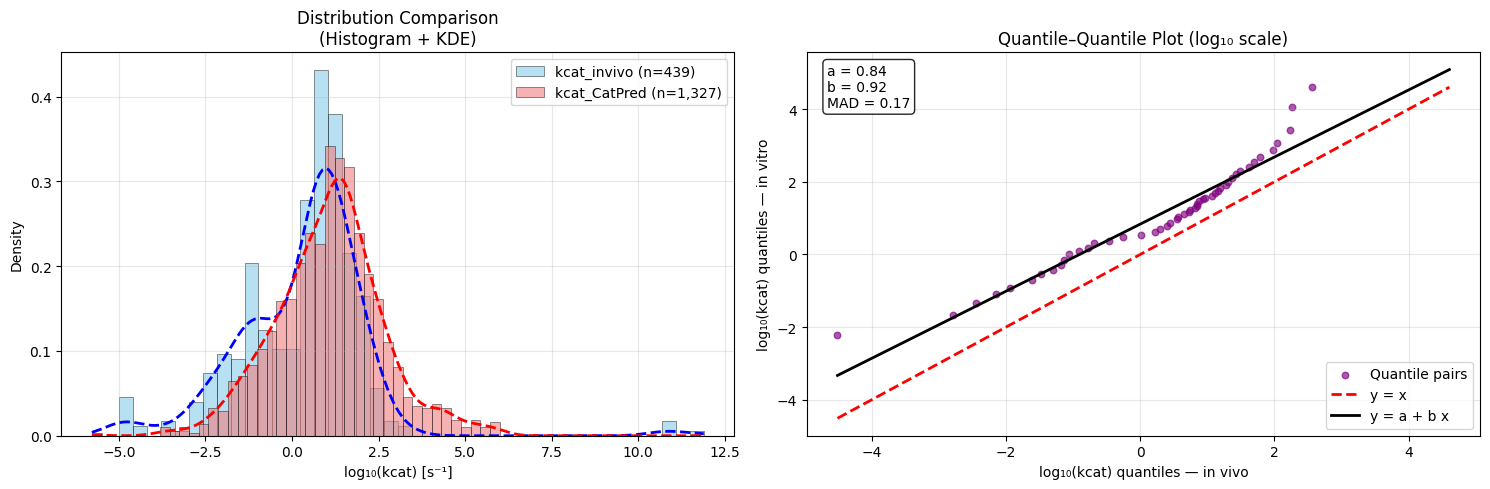

In [51]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CatPred_df, "kcat_CatPred", label1="kcat_invivo", label2="kcat_CatPred")

## ML Predicted kcats: CPI Pred

In [52]:
# Load iML1515 CPI Pred predictions
CPIPred_predictions_dir = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "CPI_kcat_predictions.csv")
CPIPred_predictions_df = pd.read_csv(CPIPred_predictions_dir)

# Drop kcat column - it's a placeholder
CPIPred_predictions_df.drop(columns=['kcat'], inplace=True)

# Get kcat by averaging predictions across 5 folds
CPIPred_predictions_df["kcat_pred"] = CPIPred_predictions_df[
    ["pred_value_0", "pred_value_1", "pred_value_2", "pred_value_3", "pred_value_4"]
].mean(axis=1)

# Keep only kcat_pred column
CPIPred_predictions_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES"}, inplace=True)
CPIPred_predictions_df = CPIPred_predictions_df[["sequence", "SMILES", "kcat_pred"]]

# There are multiple predictions for the same seq-SMILES pair, keep the largest (as done in kinGEMs)
CPIPred_predictions_df = (
    CPIPred_predictions_df
    .groupby(["sequence", "SMILES"], as_index=False)
    .max()
)

In [53]:
# Merge 
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, CPIPred_predictions_df, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------
Count                439             6,336          
Mean                 2.25e+09        2.94e+02       
Median               5.28e+00        5.76e+00       
Std Dev              3.78e+10        1.16e+04       
P10                  1.15e-02        1.36e+00       
P25                  1.51e-01        2.89e+00       
P75                  1.97e+01        1.16e+01       
P90                  9.43e+01        2.48e+01       
IQR (P25-P75)        1.96e+01        8.71e+00       
Geometric Mean       2.06e+00        5.85e+00       
Geometric Std        7.46e+01        3.65e+00       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------

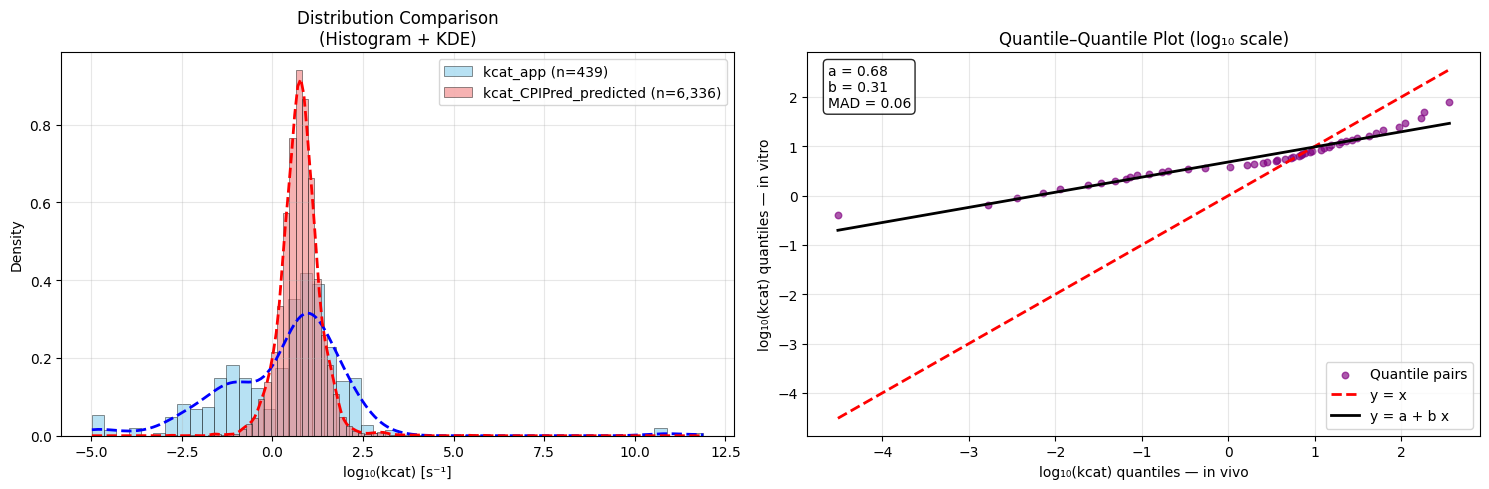

In [54]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_predictions_df, "kcat_pred", label1="kcat_app", label2="kcat_CPIPred_predicted")

## (kinGEMs tuned) ML Predicted kcats: CPI Pred

In [57]:
# Load kinGEMs tuned iML1515 CPI Pred predictions
CPIPred_tuned_dir = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "fluxes_kcat_tuned.csv")
CPIPred_tuned_df = pd.read_csv(CPIPred_tuned_dir)

# Keep only kcat_pred column
CPIPred_tuned_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES"}, inplace=True)
CPIPred_tuned_df = CPIPred_tuned_df[["sequence", "SMILES", "kcat_mean"]]

# Keep the largest kcat_mean for each seq-SMILES pair
CPIPred_tuned_df = (
    CPIPred_tuned_df
    .groupby(["sequence", "SMILES"], as_index=False)
    .max()
)

In [58]:
# Merge 
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, CPIPred_tuned_df, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_tuned
--------------------------------------------------
Count                439             6,190          
Mean                 2.25e+09        3.12e+02       
Median               5.28e+00        6.66e+00       
Std Dev              3.78e+10        1.17e+04       
P10                  1.15e-02        1.42e+00       
P25                  1.51e-01        3.08e+00       
P75                  1.97e+01        1.62e+01       
P90                  9.43e+01        5.28e+01       
IQR (P25-P75)        1.96e+01        1.31e+01       
Geometric Mean       2.06e+00        7.56e+00       
Geometric Std        7.46e+01        4.48e+00       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_tuned
--------------------------------------------------
Count  

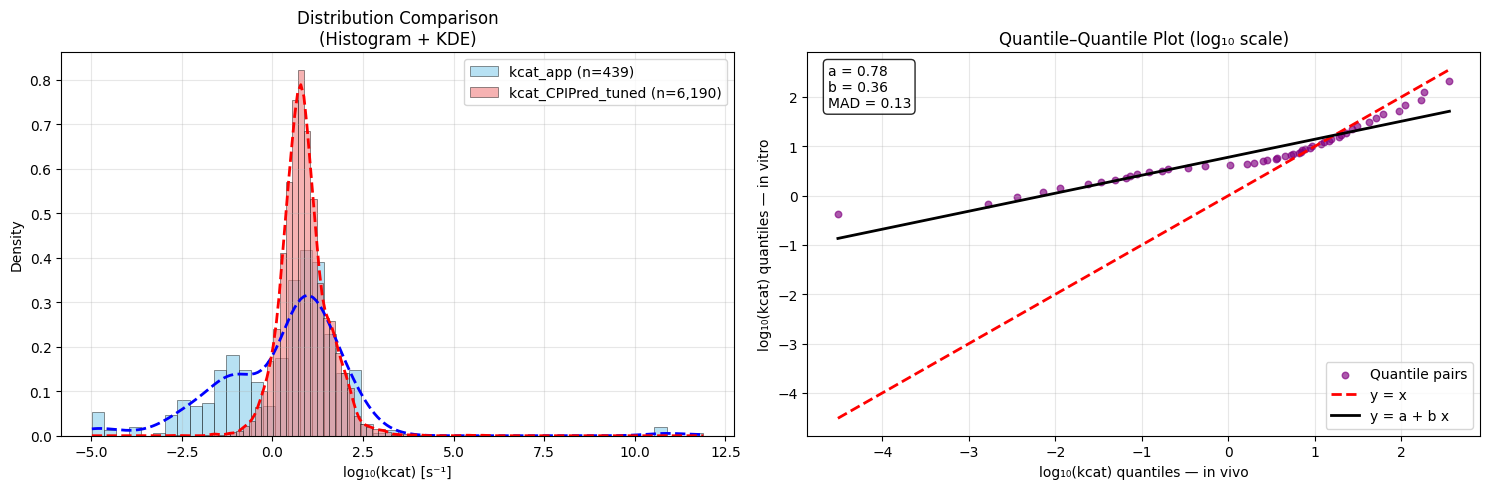

In [59]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_tuned_df, "kcat_mean", label1="kcat_app", label2="kcat_CPIPred_tuned")

## X. Filter enzymes dataframe for fluxomics matching
Drop the 'complex' cases of GPRs - such as 'b1 and (b2 or b3)'.
TO DO: 